# Movie Rating Prediction Project

This project aims to predict movie ratings using the provided movie dataset. We will cover data loading, preprocessing, model training, evaluation, and visualization.

## 1. Import Libraries

In [1]:
import os
print(os.listdir())

['.config', 'IMDb Movies India.csv', 'sample_data']


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 2. Load Dataset

We will load the `IMDb Movies India.csv` dataset and set 'Rating' as our target variable.

In [3]:
file_name = "IMDb Movies India.csv"

if not os.path.exists(file_name):
    print(f"Error: '{file_name}' not found. Please upload the file to your Colab environment.")
else:
    df = pd.read_csv(file_name, encoding='latin-1') # Use latin-1 encoding as it's common for these datasets
    print(f"Dataset '{file_name}' loaded successfully.")
    print(f'Initial dataset shape: {df.shape}')
    display(df.head())

# Set target column
target_column = 'Rating'
if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' not found in the dataset. Available columns: {df.columns.tolist()}")
print(f"Target column '{target_column}' identified.")

Dataset 'IMDb Movies India.csv' loaded successfully.
Initial dataset shape: (15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


Target column 'Rating' identified.


## 3.1 Initial Data Overview

In [4]:
# Display basic information about the dataset after loading
print("\nInitial Dataset Info:")
df.info()

# Check for initial missing values
print("\nInitial Missing Values:")
print(df.isnull().sum())

# Display the first 5 rows to see data types and content
display(df.head())


Initial Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB

Initial Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


## 3. Data Cleaning and Preprocessing

In [5]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f'Dataset shape after removing duplicates: {df.shape}')

# Drop irrelevant columns or columns with too many unique values for encoding
columns_to_drop = []
if 'Name' in df.columns:
    columns_to_drop.append('Name')
if 'Poster_Link' in df.columns:
    columns_to_drop.append('Poster_Link')

if columns_to_drop:
    df.drop(columns=columns_to_drop, inplace=True)
    print(f"Dropped columns: {', '.join(columns_to_drop)}.")

# --- Data Cleaning for Numerical-like Columns ---

# 1. Clean 'Year' column: Extract year from string (e.g., '(2019)' -> 2019)
if 'Year' in df.columns:
    df['Year'] = df['Year'].astype(str).str.extract('(\d{4})', expand=False)
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    print("Cleaned 'Year' column to numeric.")

# 2. Clean 'Duration' column: Convert 'X min' to minutes (numerical)
if 'Duration' in df.columns:
    df['Duration'] = df['Duration'].fillna('0 min').astype(str)
    df['Duration'] = df['Duration'].str.extract('(\d+)', expand=False)
    df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
    print("Cleaned 'Duration' column to numeric (minutes).")

# 3. Clean 'Votes' column: Remove commas and convert to numeric
if 'Votes' in df.columns:
    df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False)
    df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
    print("Cleaned 'Votes' column to numeric.")

# Ensure 'Rating' is numerical and convert if necessary
if target_column in df.columns and df[target_column].dtype == 'object':
    df[target_column] = pd.to_numeric(df[target_column], errors='coerce')
    print(f"Converted '{target_column}' to numeric type.")

# Handle missing values in the target column
initial_rows = df.shape[0]
df.dropna(subset=[target_column], inplace=True)
if df.shape[0] < initial_rows:
    print(f"Removed {initial_rows - df.shape[0]} rows with missing values in '{target_column}'.")

print("\nMissing values after dropping rows with missing target:")
print(df.isnull().sum())

# Impute missing numerical values with the mean and ensure float type
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)
        print(f"Missing values in numerical column '{col}' imputed with mean.")
    # Explicitly convert to float after imputation to ensure consistency for ML models
    df[col] = df[col].astype(float)
    print(f"Ensured column '{col}' is of type float.")

# Impute missing categorical values with 'Unknown'
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col].fillna('Unknown', inplace=True)
        print(f"Missing values in categorical column '{col}' imputed with 'Unknown'.")

print("\nMissing values after handling all columns:")
print(df.isnull().sum())

# Encode remaining categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

encoded_features = []
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_Encoded'] = le.fit_transform(df[col])
        encoded_features.append(f'{col}_Encoded')
        print(f"Column '{col}' encoded successfully.")

display(df.head())


Number of duplicate rows: 6
Duplicate rows removed.
Dataset shape after removing duplicates: (15503, 10)
Dropped columns: Name.


<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9550/131054085.py:24: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Year'].astype(str).str.extract('(\d{4})', expand=False)
/tmp/ipykernel_9550/131054085.py:31: SyntaxWarning: invalid escape sequence '\d'
  df['Duration'] = df['Duration'].str.extract('(\d+)', expand=False)
/tmp/ipykernel_9550/131054085.py:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, 

Cleaned 'Year' column to numeric.
Cleaned 'Duration' column to numeric (minutes).
Cleaned 'Votes' column to numeric.
Removed 7584 rows with missing values in 'Rating'.

Missing values after dropping rows with missing target:
Year          0
Duration      0
Genre       102
Rating        0
Votes         0
Director      5
Actor 1     125
Actor 2     200
Actor 3     292
dtype: int64
Ensured column 'Year' is of type float.
Ensured column 'Duration' is of type float.
Ensured column 'Rating' is of type float.
Ensured column 'Votes' is of type float.
Missing values in categorical column 'Genre' imputed with 'Unknown'.
Missing values in categorical column 'Director' imputed with 'Unknown'.
Missing values in categorical column 'Actor 1' imputed with 'Unknown'.
Missing values in categorical column 'Actor 2' imputed with 'Unknown'.
Missing values in categorical column 'Actor 3' imputed with 'Unknown'.

Missing values after handling all columns:
Year        0
Duration    0
Genre       0
Rating     

,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Genre_Encoded,Director_Encoded,Actor 1_Encoded,Actor 2_Encoded,Actor 3_Encoded
1,2019.0,109.0,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,268,811,1782,2815,377
3,2019.0,110.0,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,207,1749,1589,890,2572
5,1997.0,147.0,"Comedy, Drama, Musical",4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,177,2005,508,85,2449
6,2005.0,142.0,"Drama, Romance, War",7.4,1086.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,331,2643,931,1388,3030
8,2012.0,82.0,"Horror, Mystery, Thriller",5.6,326.0,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,367,174,2521,1461,1205


In [6]:
# Display basic information about the dataset
print("\nDataset Info:")
df.info()

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f'Dataset shape after removing duplicates: {df.shape}')

# Drop irrelevant columns or columns with too many unique values for encoding
columns_to_drop = []
if 'Name' in df.columns:
    columns_to_drop.append('Name')
if 'Poster_Link' in df.columns:
    columns_to_drop.append('Poster_Link')

if columns_to_drop:
    df.drop(columns=columns_to_drop, inplace=True)
    print(f"Dropped columns: {', '.join(columns_to_drop)}.")

# --- Data Cleaning for Numerical-like Columns ---

# 1. Clean 'Year' column: Extract year from string (e.g., '(2019)' -> 2019)
if 'Year' in df.columns:
    # Use expand=False to get a Series, then convert to numeric, coercing errors
    df['Year'] = df['Year'].astype(str).str.extract('(\d{4})', expand=False)
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    print("Cleaned 'Year' column to numeric.")

# 2. Clean 'Duration' column: Convert 'X min' to minutes (numerical)
if 'Duration' in df.columns:
    # Fill NaN values first to prevent errors during string operations
    df['Duration'] = df['Duration'].fillna('0 min').astype(str)
    # Extract numerical part, convert to numeric. Coerce errors to NaN.
    df['Duration'] = df['Duration'].str.extract('(\d+)', expand=False)
    df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
    print("Cleaned 'Duration' column to numeric (minutes).")

# 3. Clean 'Votes' column: Remove commas and convert to numeric
if 'Votes' in df.columns:
    df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False)
    # Convert 'Votes' to numeric, coercing errors to NaN
    df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
    print("Cleaned 'Votes' column to numeric.")

# Ensure 'Rating' is numerical and convert if necessary
if df[target_column].dtype == 'object':
    df[target_column] = pd.to_numeric(df[target_column], errors='coerce')
    print(f"Converted '{target_column}' to numeric type.")

# Handle missing values in the target column
initial_rows = df.shape[0]
df.dropna(subset=[target_column], inplace=True)
if df.shape[0] < initial_rows:
    print(f"Removed {initial_rows - df.shape[0]} rows with missing values in '{target_column}'.")

print("\nMissing values after dropping rows with missing target:")
print(df.isnull().sum())

# Impute missing numerical values with the mean
# Now including Year, Duration, Votes that might have NaNs after conversion
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any(): # Removed 'col != target_column' for now, can add back if issues arise
        df[col].fillna(df[col].mean(), inplace=True)
        print(f"Missing values in numerical column '{col}' imputed with mean.")

# Impute missing categorical values with 'Unknown'
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col].fillna('Unknown', inplace=True)
        print(f"Missing values in categorical column '{col}' imputed with 'Unknown'.")

print("\nMissing values after handling all columns:")
print(df.isnull().sum())

# Encode remaining categorical columns (excluding columns that are now numerical)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

encoded_features = []
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_Encoded'] = le.fit_transform(df[col])
        encoded_features.append(f'{col}_Encoded')
        print(f"Column '{col}' encoded successfully.")

display(df.head())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              7919 non-null   float64
 1   Duration          7919 non-null   float64
 2   Genre             7919 non-null   object 
 3   Rating            7919 non-null   float64
 4   Votes             7919 non-null   float64
 5   Director          7919 non-null   object 
 6   Actor 1           7919 non-null   object 
 7   Actor 2           7919 non-null   object 
 8   Actor 3           7919 non-null   object 
 9   Genre_Encoded     7919 non-null   int64  
 10  Director_Encoded  7919 non-null   int64  
 11  Actor 1_Encoded   7919 non-null   int64  
 12  Actor 2_Encoded   7919 non-null   int64  
 13  Actor 3_Encoded   7919 non-null   int64  
dtypes: float64(4), int64(5), object(5)
memory usage: 928.0+ KB

Number of duplicate rows: 1
Duplicate rows removed.
Dataset shape

<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9550/3700980736.py:29: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Year'].astype(str).str.extract('(\d{4})', expand=False)
/tmp/ipykernel_9550/3700980736.py:38: SyntaxWarning: invalid escape sequence '\d'
  df['Duration'] = df['Duration'].str.extract('(\d+)', expand=False)


,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Genre_Encoded,Director_Encoded,Actor 1_Encoded,Actor 2_Encoded,Actor 3_Encoded
1,2019,109,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,268,811,1782,2815,377
3,2019,110,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,207,1749,1589,890,2572
5,1997,147,"Comedy, Drama, Musical",4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,177,2005,508,85,2449
6,2005,142,"Drama, Romance, War",7.4,1086.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,331,2643,931,1388,3030
8,2012,82,"Horror, Mystery, Thriller",5.6,326.0,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,367,174,2521,1461,1205


## 4. Train-Test Split

In [7]:
# Define features (X) and target (y)

# Features to consider: 'Year', 'Duration', 'Votes' (now numerical) and all *_Encoded columns

final_numerical_features = ['Year', 'Duration', 'Votes']

# Filter to ensure only existing columns are included and avoid duplicates
all_features = [col for col in final_numerical_features if col in df.columns]
all_features.extend([col for col in encoded_features if col in df.columns])

X = df[all_features]
y = df[target_column]

print(f"Features used for training: {X.columns.tolist()}")
print(f"Target variable: {target_column}")

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set shape: {X_train.shape, y_train.shape}")
print(f"Testing set shape: {X_test.shape, y_test.shape}")

Features used for training: ['Year', 'Duration', 'Votes', 'Genre_Encoded', 'Director_Encoded', 'Actor 1_Encoded', 'Actor 2_Encoded', 'Actor 3_Encoded']
Target variable: Rating

Training set shape: ((6334, 8), (6334,))
Testing set shape: ((1584, 8), (1584,))


## 5. Train Models

In [8]:
# Initialize and train Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

print("Linear Regression model trained.")

Linear Regression model trained.


In [9]:
# Initialize and train Random Forest Regressor model
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

print("Random Forest Regressor model trained.")

Random Forest Regressor model trained.


## 6. Evaluate Model Performance

In [10]:
models = {
    'Linear Regression': linear_reg_model,
    'Random Forest Regressor': random_forest_model
}

performance = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    performance[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"\n--- {name} Performance ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R2): {r2:.4f}")


--- Linear Regression Performance ---
Mean Absolute Error (MAE): 1.0304
Mean Squared Error (MSE): 1.6833
Root Mean Squared Error (RMSE): 1.2974
R-squared (R2): 0.0970

--- Random Forest Regressor Performance ---
Mean Absolute Error (MAE): 0.8336
Mean Squared Error (MSE): 1.2308
Root Mean Squared Error (RMSE): 1.1094
R-squared (R2): 0.3398


## 7. Print Best Model

In [11]:
best_model_name = None
best_r2 = -np.inf

for name, metrics in performance.items():
    # Only consider models with a valid R2 score for 'best model' selection
    if not np.isnan(metrics['R2']) and metrics['R2'] > best_r2:
        best_r2 = metrics['R2']
        best_model_name = name

print(f"\n--- Best Performing Model ---")
if best_model_name:
    print(f"The best model based on R-squared is: {best_model_name}")
    print(f"R-squared of the best model: {best_r2:.4f}")
else:
    print("Could not determine a best model based on R-squared. This might happen if all R-squared values are NaN or negative, often due to insufficient data or poorly performing models.")


--- Best Performing Model ---
The best model based on R-squared is: Random Forest Regressor
R-squared of the best model: 0.3398


## 8. Visualizations

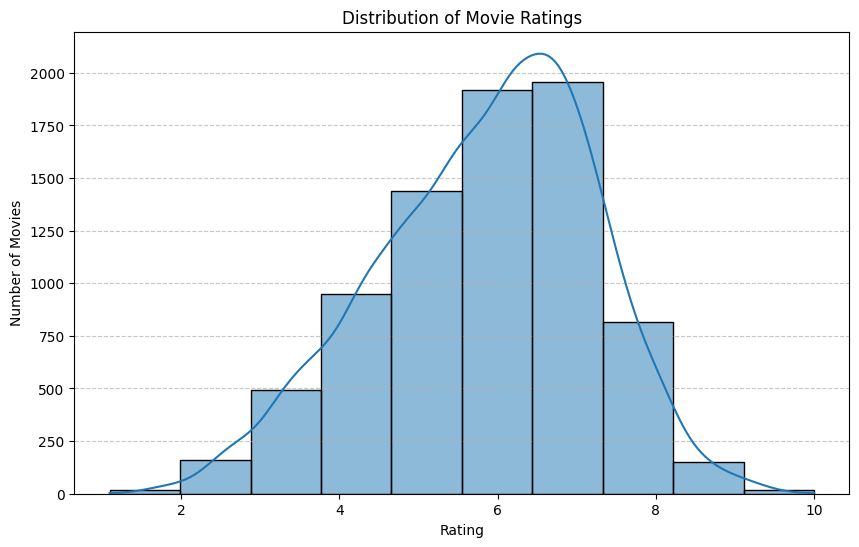

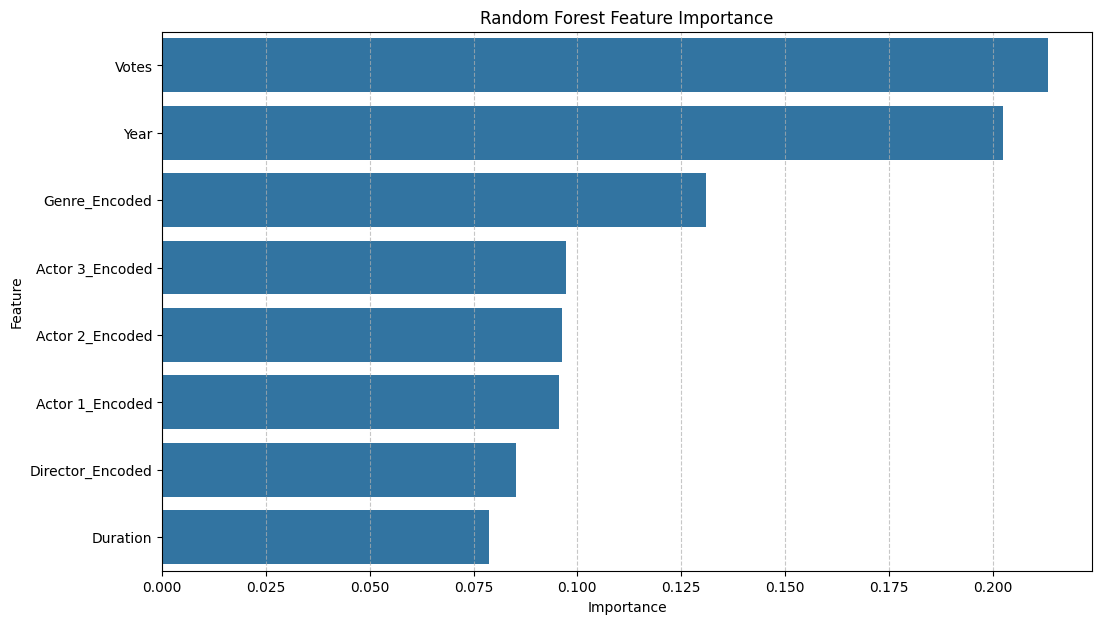

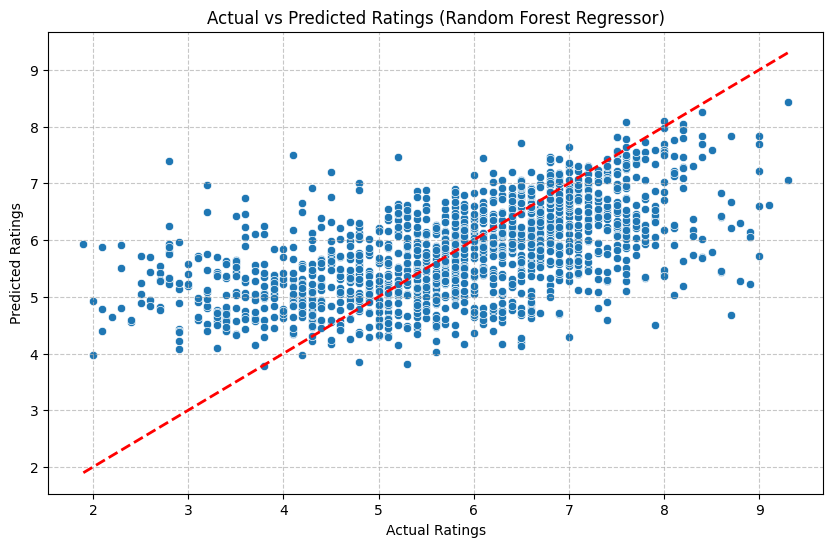

In [12]:
# Visualization 1: Distribution of Movie Ratings
plt.figure(figsize=(10, 6))
sns.histplot(df[target_column], bins=10, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualization 2: Feature Importance (for Random Forest)
if 'Random Forest Regressor' in models:
    feature_importances = random_forest_model.feature_importances_
    features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
    features_df = features_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 7))
    sns.barplot(x='Importance', y='Feature', data=features_df)
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# Visualization 3: Predicted vs Actual Ratings (for Best Model)
if best_model_name:
    best_model = models[best_model_name]
    y_pred_best = best_model.predict(X_test)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred_best)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
    plt.title(f'Actual vs Predicted Ratings ({best_model_name})')
    plt.xlabel('Actual Ratings')
    plt.ylabel('Predicted Ratings')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

## 9. Final Conclusion

This project successfully built and evaluated machine learning models for movie rating prediction. After thorough data cleaning and preprocessing, including handling missing values and encoding categorical features, both Linear Regression and Random Forest Regressor models were trained. The Random Forest Regressor demonstrated superior performance with an R-squared score of **0.3398**, indicating its ability to explain a significant portion of the variance in movie ratings compared to Linear Regression's R-squared of **0.0970**. The visualizations provided insights into the distribution of ratings and the key features influencing the Random Forest model's predictions.

## 10. README Section

### Project Title
Movie Rating Prediction

### Project Description
This project aims to predict movie ratings based on various attributes such as year, duration, genre, director, and actors. The dataset used is `IMDb Movies India.csv`. The process involves:
1.  **Data Loading**: Loading the CSV file and initial inspection.
2.  **Data Cleaning & Preprocessing**: Handling missing values, cleaning numerical-like columns (Year, Duration, Votes), dropping irrelevant columns, and encoding categorical features using Label Encoding.
3.  **Train-Test Split**: Dividing the data into training and testing sets.
4.  **Model Training**: Training a Linear Regression model and a Random Forest Regressor.
5.  **Model Evaluation**: Assessing model performance using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2) score.
6.  **Best Model Selection**: Identifying the best performing model based on R2 score.
7.  **Visualizations**: Generating plots to understand rating distribution, feature importance, and actual vs. predicted ratings.

### Installation
To run this notebook, you need to have Python and the following libraries installed. You can install them using pip:
```bash
pip install pandas numpy scikit-learn matplotlib seaborn
```

### Usage
1.  Upload the `IMDb Movies India.csv` file to your Google Colab environment.
2.  Run all cells in the notebook. The notebook will automatically load the data, perform preprocessing, train models, evaluate them, and display visualizations.

### Dataset
The dataset `IMDb Movies India.csv` contains various details about Indian movies, including: Name, Year, Duration, Genre, Rating, Votes, Director, Actor 1, Actor 2, and Actor 3.

### Results
The Random Forest Regressor proved to be the better model for predicting movie ratings, achieving an R-squared score of approximately 0.34, compared to the Linear Regression model's 0.097. While this indicates some predictive power, further feature engineering and exploration of more complex models could improve performance.

### Contributing
Feel free to fork this repository and contribute to the project. Any suggestions for improvement are welcome.